In [1]:
#!/usr/bin/env python3.11
# -*- coding: utf-8 -*-

import PIL
import PIL.Image
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage.filters import gaussian

def load_npz_file(fn):
    filename, file_extension = os.path.splitext(fn)
    if file_extension == '.npz' or os.path.exists(filename + '.npz'):
        npz_file = np.load(fn,allow_pickle=True)
        E_xy_histo = npz_file['E_xy']
        return E_xy_histo


def generate_bounding_boxes(grid_size, box_size, offset, spacing, pads):
    positions = {}
    rows, cols = grid_size
    box_h, box_w = box_size
    x_offset, y_offset = offset
    x_spacing, y_spacing = spacing

    count = 1
    for i in range(rows):
        for j in range(cols):
            x1 = x_offset + i * (box_h + x_spacing)
            x2 = x1 + box_h
            y1 = y_offset + j * (box_w + y_spacing)
            y2 = y1 + box_w
            positions[pads[i*cols + j]] = (x1, x2, y1, y2)
            count += 1
    
    return positions
    

In [2]:
pads_e_xy = load_npz_file("data/pigment_palette/GEM_Cr_PBS1_PadsPalette_ArCO2_80_20_Gain_35_Thr_35_HV3490_Xray_50kV_1mA_Pinhol_2mm_sum_3-23_GainCorr_Fe.npz")
pads_e_xy = np.fliplr(np.rot90(pads_e_xy, k=1))

pad_names = [
    "mn_fe",          # Umbra
    "ca_zn",          # Żółta neapolitańska ???
    "s_as_ca_zn",     # Aurypigment
    "ca_zn_pb",       # Żółta neapolitańska ???
    "mn",             # Fiolet manganowy
    
    "s_hg",           # Umbra
    "wood",           # Deska (Drewno)
    "cr",             # Zieleń chromowa
    "ti",             # Biel tytanowa
    "s_as",           # Realgar (Madryt)

    "si_zr",          # Ceruleum
    "fe",             # Raw Siena
    "na_al_si_s",     # Ultramaryna
    "s_k_cd",         # Żółta kadmowa
    "si_k_co",        # Smalta

    "sn_pb",          # Żółta cynowo-ołowiowa
    "cu",             # Malachit
    "pb",             # Minia ołowiowa
    "ag",             # Srebro
    "al",             # Aluminium

    "s_zn",           # Biel cynkowa
    "co",             # Niebieski kobaltowy
    "s_ba",           # Biel barytowa
    "s_au",           # Złoto
    "cu_zn"           # Mosiądz
]
# # - W detektorze GEM_Cr zupełnie nie zaobserwuję zewnętrznego!!! sygnału od: Al, Ag, S, Si, Na

['mn_fe', 'ca_zn', 'as_ca_zn', 'ca_zn_pb', 'mn', 'hg', 'wood', 'cr', 'ti', 'as', 'zr', 'fe', '', 'k_cd', 'k_co', 'pb', 'cu', 'pb', '', '', 'zn', 'co', 'ba', 'au', 'cu_zn']
{'mn_fe': (9, 25, 9, 25), 'ca_zn': (9, 25, 31, 47), 's_as_ca_zn': (9, 25, 53, 69), 'ca_zn_pb': (9, 25, 75, 91), 'mn': (9, 25, 97, 113), 's_hg': (31, 47, 9, 25), 'wood': (31, 47, 31, 47), 'cr': (31, 47, 53, 69), 'ti': (31, 47, 75, 91), 's_as': (31, 47, 97, 113), 'si_zr': (53, 69, 9, 25), 'fe': (53, 69, 31, 47), 'na_al_si_s': (53, 69, 53, 69), 's_k_cd': (53, 69, 75, 91), 'si_k_co': (53, 69, 97, 113), 'sn_pb': (75, 91, 9, 25), 'cu': (75, 91, 31, 47), 'pb': (75, 91, 53, 69), 'ag': (75, 91, 75, 91), 'al': (75, 91, 97, 113), 's_zn': (97, 113, 9, 25), 'co': (97, 113, 31, 47), 's_ba': (97, 113, 53, 69), 's_au': (97, 113, 75, 91), 'cu_zn': (97, 113, 97, 113)}
dict_keys(['mn_fe', 'ca_zn', 'as_ca_zn', 'ca_zn_pb', 'mn', 'hg', 'wood', 'cr', 'ti', 'as', 'zr', 'fe', 'k_cd', 'k_co', 'pb', 'cu', 'zn', 'co', 'ba', 'au', 'cu_zn'])


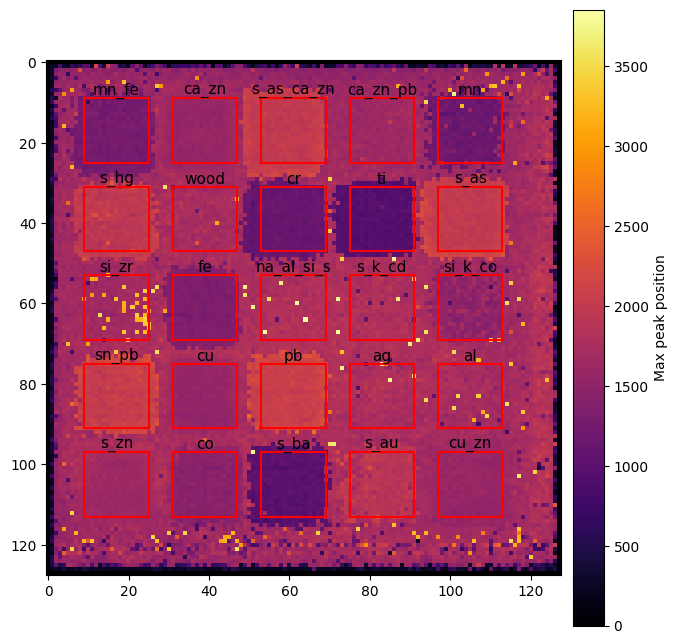

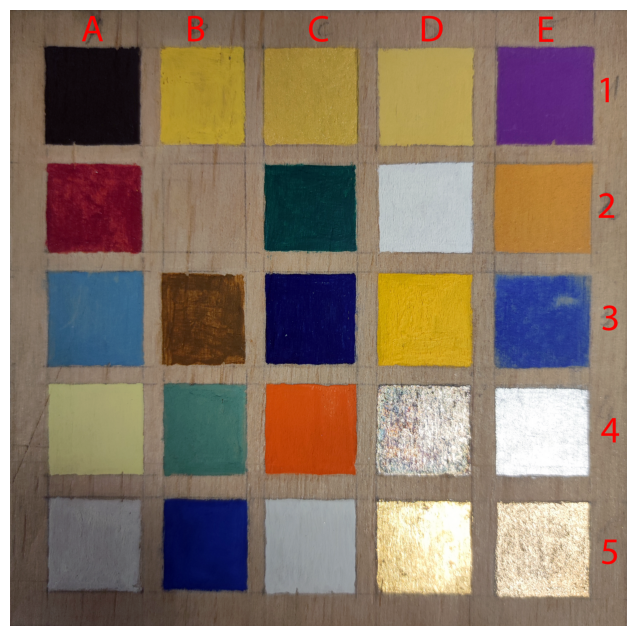

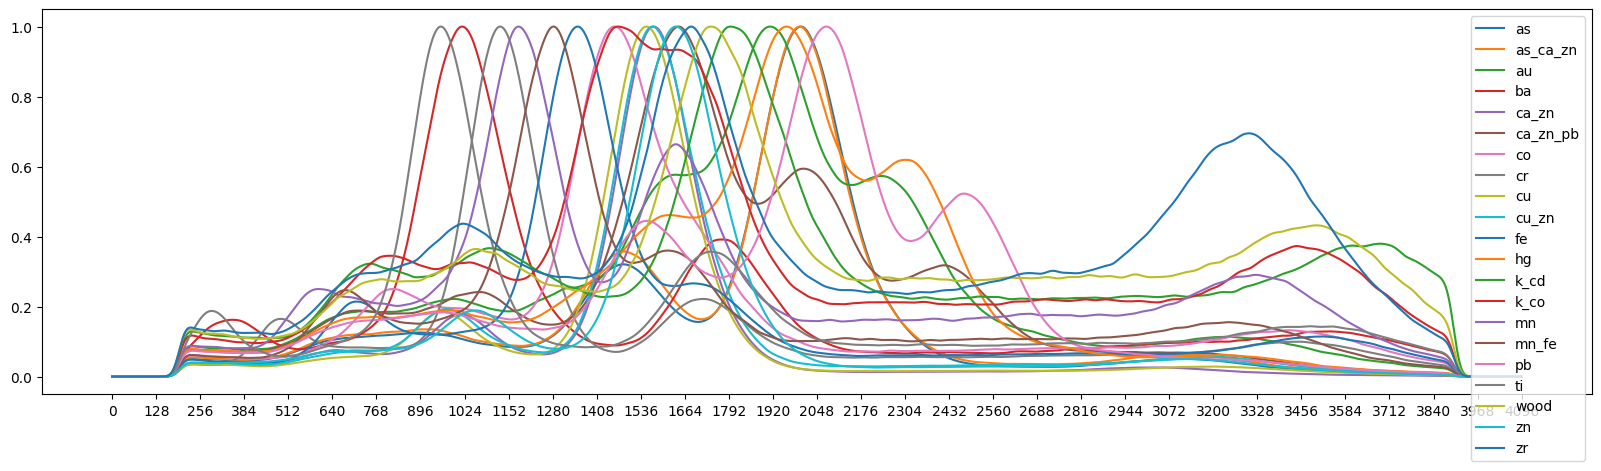

In [41]:
# # - W detektorze GEM_Cr zupełnie nie zaobserwuję zewnętrznego!!! sygnału od: Al, Ag, S, Si, Na

# max_E = 2048
# bins_short = np.arange(0, 2 * max_E)[:-2]

def filtered_element_name(pad_name, excluded_elements):
    return "_".join([name for name in pad_name.split("_") if name not in excluded_elements])

def apply_padding(pads_e_xy, padding_size):
    pads_e_xy[:, :, :padding_size] = 0
    pads_e_xy[:, :, -padding_size:] = 0

def select_pads(pads_e_xy, pad_positions, E_shift):
    return { name: pads_e_xy[x1:x2, y1:y2].astype(float) / (1 << E_shift) for name, (x1, x2, y1, y2) in pad_positions.items() }

def filter_pads(selected_pads, excluded_elements):
    filtered_pads = {}
    for name, pad in selected_pads.items():
        filtered_name = filtered_element_name(name, excluded_elements)
        if filtered_name != "":
            filtered_pads[filtered_name] = pad
    return filtered_pads

def plot_pads_map(pads_e_xy, pad_positions):
    fig, ax = plt.subplots(figsize=(8, 8))
    pads_map = np.argmax(pads_e_xy, axis=2)
    im = ax.imshow(pads_map, cmap="inferno")
    cbar = plt.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Max peak position")
    
    for pad_name, (x1, x2, y1, y2) in pad_positions.items():
        width, height = y2 - y1, x2 - x1
        rect = patches.Rectangle((y1, x1), width, height, linewidth=1.5, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(y1 + width // 2, x1 - 2, pad_name, color='black', fontsize=11, ha='center', va='center')

def plot_palette_image(image_path):
    plt.figure(123, figsize=(8, 8))
    img = PIL.Image.open(image_path)
    plt.imshow(img, alpha=1)
    plt.axis('off')

def plot_pads(selected_pads):
    plt.figure(figsize=(20, 5))
    
    sorted_pads = dict(sorted(selected_pads.items()))

    for name, pad_e_xy in sorted_pads.items():
        pad_avg = gaussian(np.mean(pad_e_xy, axis=(0, 1)), sigma=16)
        plt.plot(pad_avg / np.max(pad_avg), label=name)
    
    plt.xticks(np.arange(0, 4097, 128))
    plt.legend()

E_shift = 2
excluded_elements = {"al", "ag", "s", "si", "na", "sn"}
padding_size = 196
grid_size = (5, 5)
box_size = (16, 16)
offset = (9, 9)
spacing = (6, 6)
image_path = "data/pigment_palette/pads_palette_photo.png"

print([filtered_element_name(name, excluded_elements) for name in pad_names])

apply_padding(pads_e_xy, padding_size)

pad_positions = generate_bounding_boxes(grid_size, box_size, offset, spacing, pad_names)
print(pad_positions)

selected_pads = select_pads(pads_e_xy, pad_positions, E_shift)
filtered_pads = filter_pads(selected_pads, excluded_elements)
print(filtered_pads.keys())

plot_pads_map(pads_e_xy, pad_positions)
plot_palette_image(image_path)
plot_pads(filtered_pads)





21


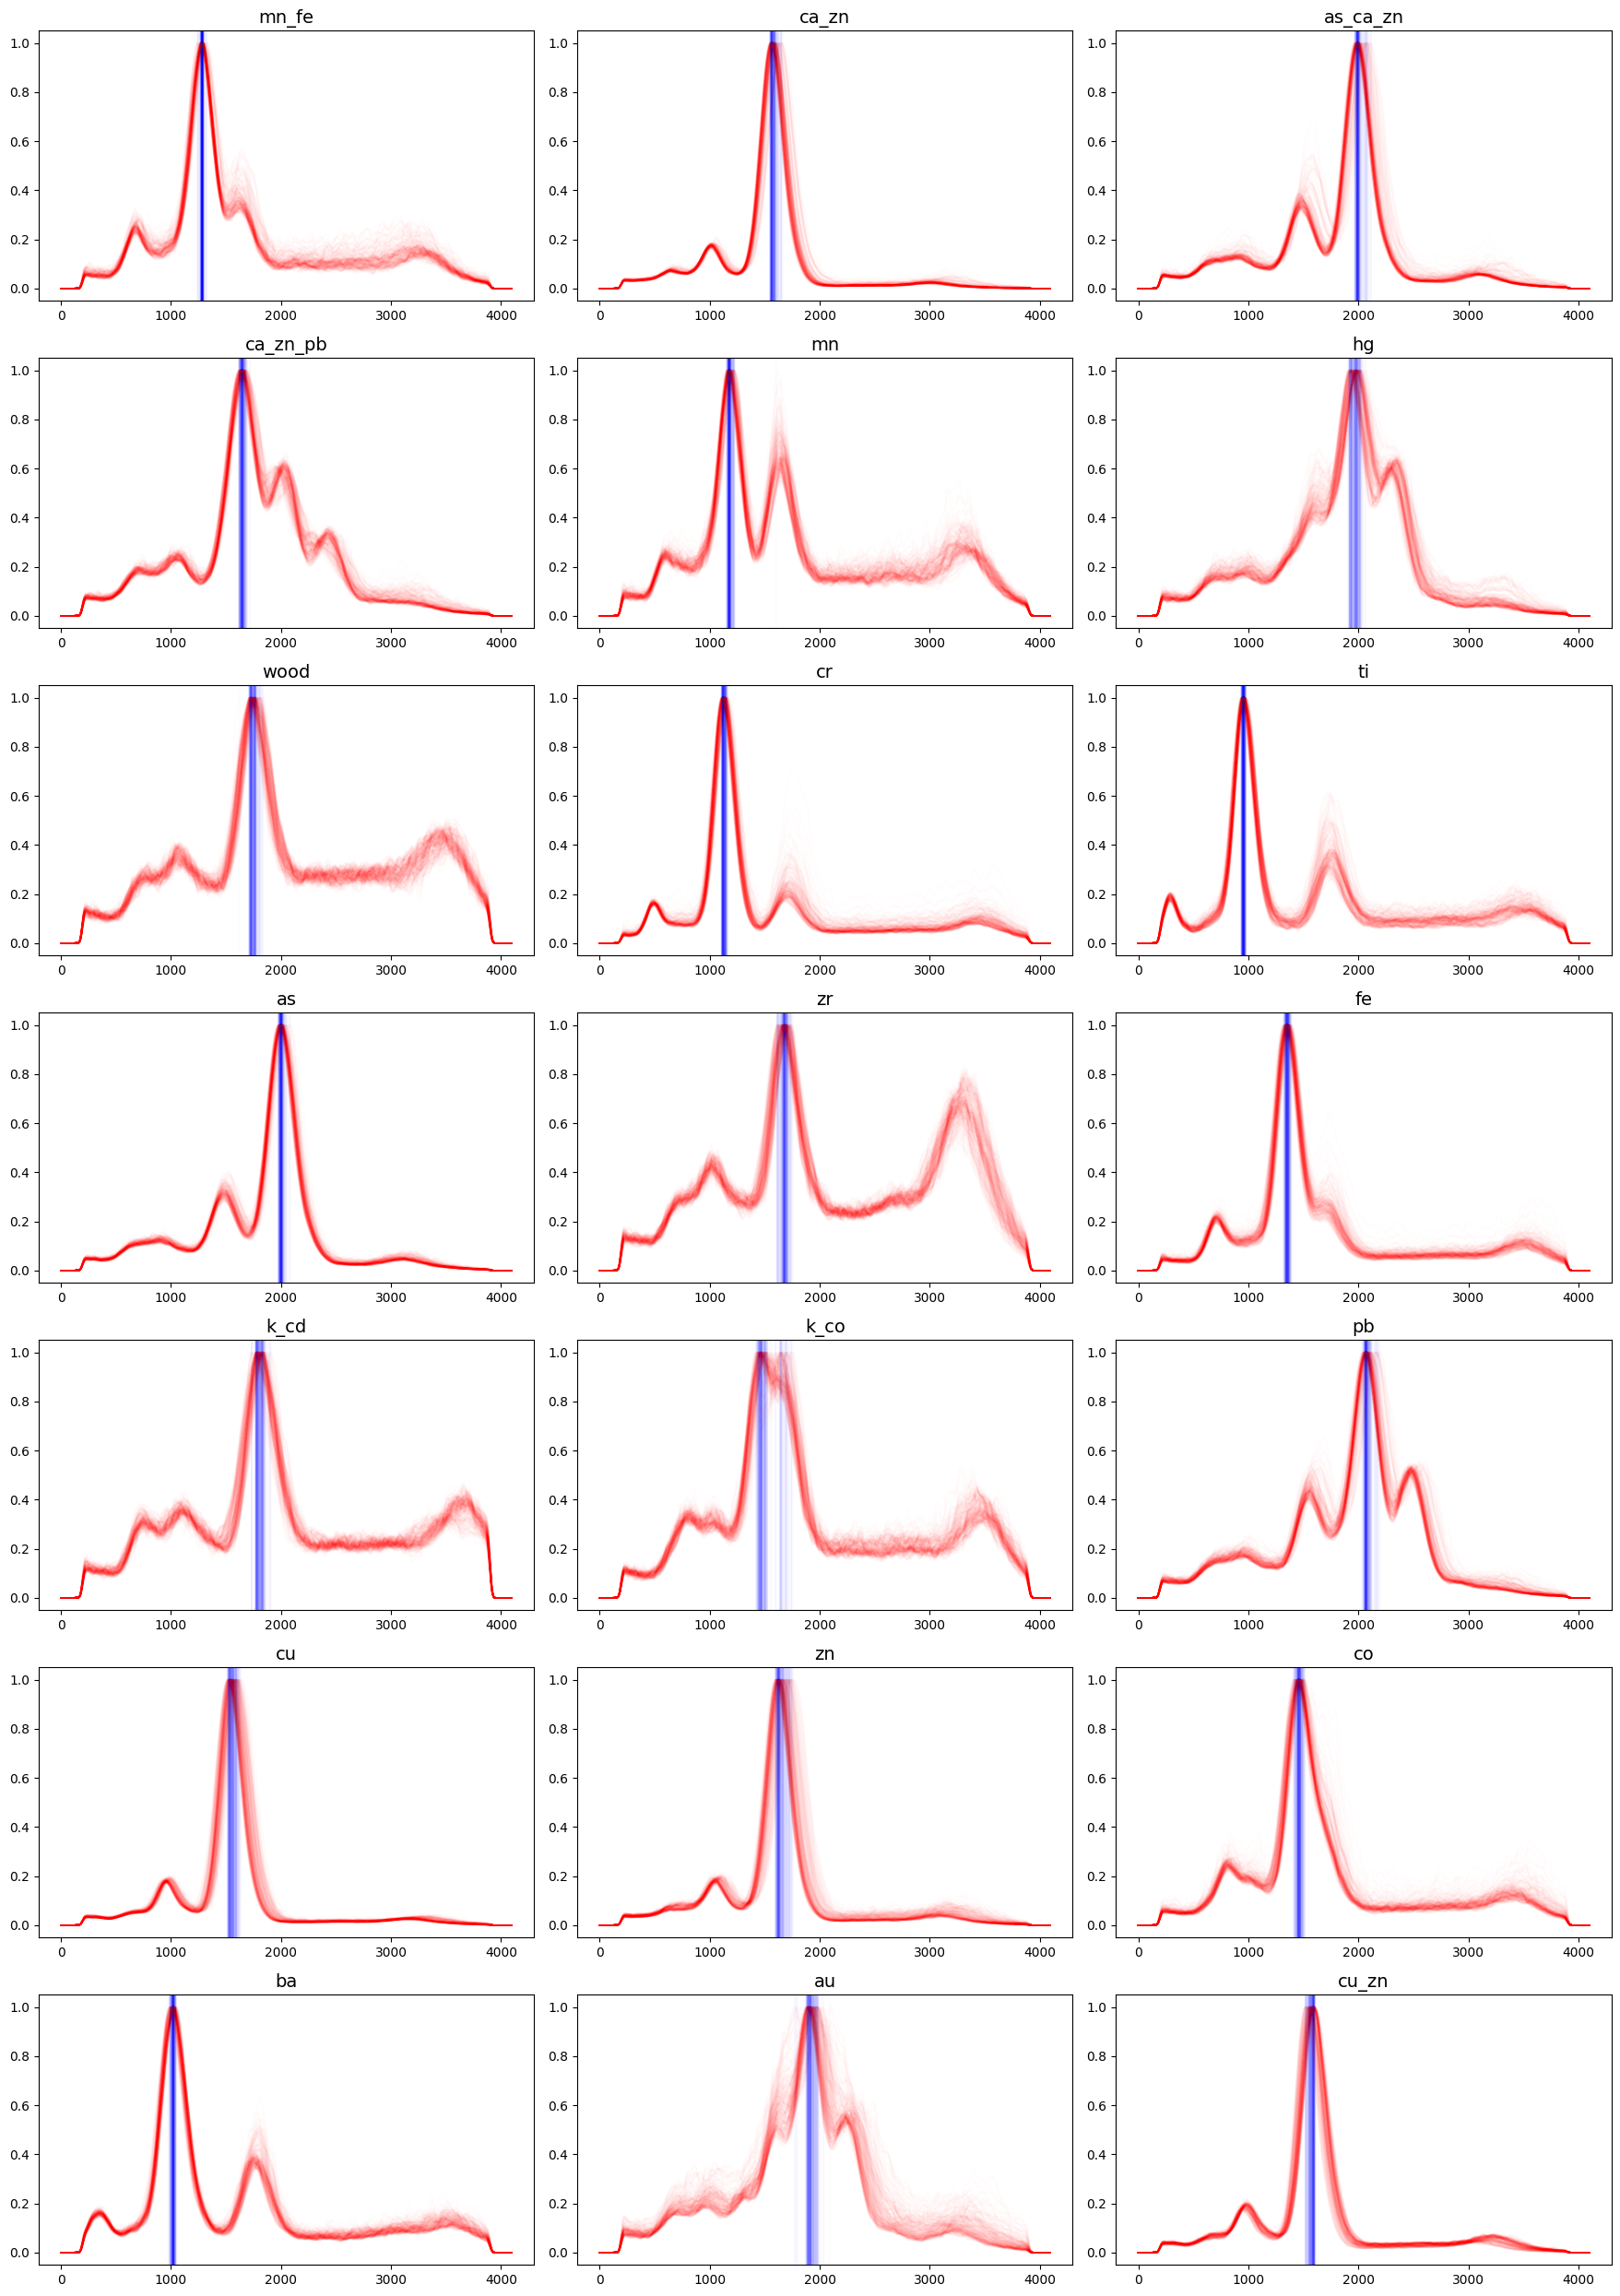

In [ ]:
from random import randint 
print(len(filtered_pads.keys()))

proportion = 21/29.7
height = 25
width = height * proportion
fig, axes = plt.subplots(7, 3, figsize=(width, height))
axes = axes.flatten()

for idx, (pad_name, pad) in enumerate(filtered_pads.items()):
    pad = gaussian(pad, sigma=1, channel_axis=2)
    
    for i in range(0, 16):
        for j in range(0, 16):
            spectrum = gaussian(pad[i][j], sigma=16)
            spectrum = spectrum / np.max(spectrum)
            axes[idx].plot(spectrum, color="red", alpha=0.01)
            axes[idx].axvline(np.argmax(spectrum), color="blue", alpha=0.01)

            first_peak_end = 50
            first
            second_peak_position = np.argmax(spectrum[second_peak_start:second_peak_end])
            second_peak_position += second_peak_start
            axes[idx].axvline(second_peak_position, color="green", alpha=0.01)

    axes[idx].set_title(pad_name, fontsize=14)

plt.tight_layout()
plt.show()

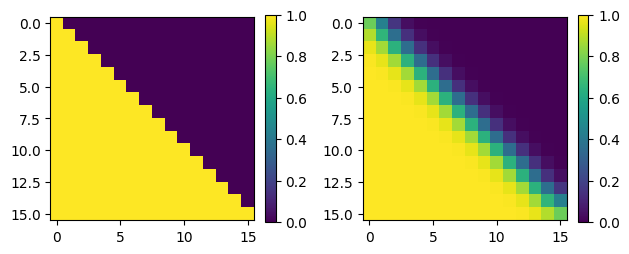

In [18]:
checkerboard = np.tril(np.ones((16, 16), dtype=np.float32))
checkerboard = checkerboard.reshape((*checkerboard.shape, 1))
plt.subplot(1, 2, 1)
plt.imshow(checkerboard)
plt.colorbar(fraction=0.046)
plt.subplot(1, 2, 2)
plt.imshow(gaussian(checkerboard, sigma=1, channel_axis=2))
plt.colorbar(fraction=0.046)
plt.tight_layout()

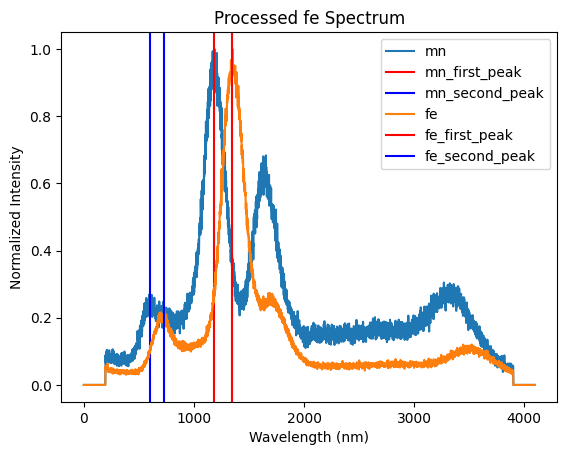

In [6]:
import random

peak_lines = {
    "fe": "k_alpha"
}

colors = ["red", "green", "blue"]
for name, pad in selected_pads.items():
    average_spectrum = gaussian(np.average(pad, axis=(0, 1)), sigma=0)
    first_peak_position = np.argmax(average_spectrum)
    if name not in ["s_hg", "s_au", "mn_fe"]:
        if  name in ["mn", "fe"]:
            boundry_left = first_peak_position-700
            boundry_right = first_peak_position-500
            second_peak_position = np.argmax(average_spectrum[boundry_left:boundry_right]) + boundry_left
            # plt.figure(random.randint(1, int(10e10)))
            plt.plot(average_spectrum / np.max(average_spectrum), label=name)
            # plt.axvline(boundry_left, color="green")
            # plt.axvline(boundry_right, color="green")

            plt.axvline(first_peak_position, label=f"{name}_first_peak", color="red")
            plt.axvline(second_peak_position, label=f"{name}_second_peak", color="blue")
            plt.title(f"Processed {name} Spectrum")
            plt.xlabel("Wavelength (nm)")
            plt.ylabel("Normalized Intensity")
            plt.legend()
